# Actividad integradora — Clasificación de defectos (capsule, MVTec-AD)

**Consigna:** desarrollar una aplicación de visión computacional entrenando un modelo de clasificación con un dataset a elección, generando proceso de entrenamiento y métricas de performance, e informe final (problema, dataset, resultados, conclusiones).

Este notebook es el punto de partida: replica la estructura del ejemplo del profesor (`transfer_learning.ipynb`) pero sobre MVTec-AD `capsule` en clasificación **binaria** (buena vs. defectuosa) con una CNN sencilla.

> En local requiere: `pip install -r requirements.txt`. En Colab las dependencias ya vienen instaladas; la celda de setup de abajo descarga los datos.


In [6]:
# Setup para Google Colab: descargar el recorte `capsule` (~387 MB).
# Si se corre en local con los datos ya presentes, saltea esta celda.
from pathlib import Path

# Si la carpeta de datos no existe, estamos en Colab: instalar descargador y bajar datos
if not Path("datasets/mvtec-ad/capsule/train/good").exists():
    !pip install -q -U "huggingface_hub[cli]"
    !hf download foersben/mvtec-ad --repo-type dataset --include "capsule/*" --local-dir datasets/mvtec-ad
else:
    # Los datos ya estan en disco: no se descarga nada
    print("Datos ya presentes, no se descarga nada.")


Datos ya presentes, no se descarga nada.


## 1. Problema y dataset

**Problema (informe.md):** clasificar imágenes de productos industriales según su estado visual.

**Dataset:** MVTec-AD, categoría `capsule` — ver [proyecto original](https://www.mvtec.com/research-teaching/datasets/mvtec-ad) y `README.md` para la descarga. Estructura local en `datasets/mvtec-ad/capsule/`:

- `train/good/` — solo piezas buenas (el dataset original es no supervisado).
- `test/{crack, faulty_imprint, good, poke, scratch, squeeze}/` — buenas y defectuosas.
- `ground_truth/` — máscaras (no se usan en clasificación).

Para clasificación supervisada binaria se reagrupa todo en `good (0)` vs `defectuosa (1)` con split estratificado.

In [7]:
import pathlib  # manejar rutas de carpetas del dataset
import numpy as np  # numeros y arreglos (cada imagen es una matriz de numeros)
import matplotlib.pyplot as plt  # graficos de curvas y matrices
%matplotlib inline  # mostrar los graficos dentro del notebook

import tensorflow as tf  # framework de deep learning
from tensorflow.keras import Sequential, layers  # armar la red apilando bloques
from tensorflow.keras.callbacks import EarlyStopping  # frenar solo si deja de mejorar
from sklearn.model_selection import train_test_split  # separar train/test
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay  # metricas


train/good: 219
test/crack: 23
test/faulty_imprint: 22
test/good: 23
test/poke: 21
test/scratch: 23
test/squeeze: 20


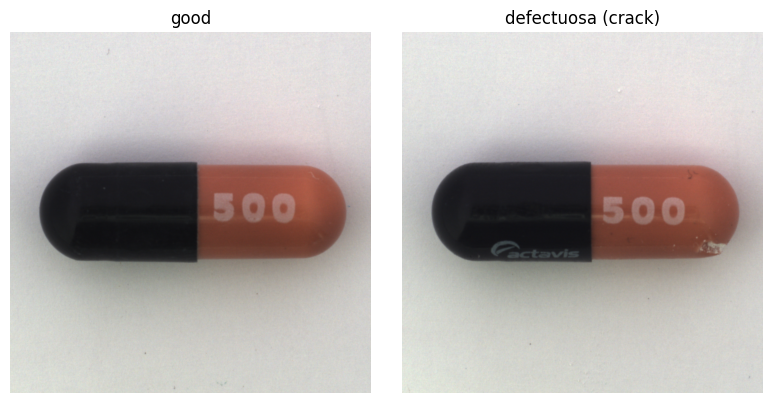

In [8]:
DATA_DIR = pathlib.Path("datasets/mvtec-ad/capsule")  # carpeta raiz del recorte capsule

# Corregir ruta en caso de que Hugging Face la haya descargado con subestructura duplicada
if not (DATA_DIR / "train").exists() and (DATA_DIR / "capsule" / "train").exists():
    DATA_DIR = DATA_DIR / "capsule"  # usar la subcarpeta real

# Si los datos no estan, frenar con un error claro (hay que correr la celda de Setup)
if not DATA_DIR.exists() or not (DATA_DIR / "train").exists():
    raise FileNotFoundError(f"No se encontró la carpeta del dataset en '{DATA_DIR}'. Asegúrate de haber ejecutado con éxito la celda de Setup (c00setup).")

# Conteo por carpeta (exploración rápida): cuantas fotos trae cada clase
for split in ["train", "test"]:
    for cls in sorted((DATA_DIR / split).iterdir()):
        n = len(list(cls.glob("*.png")))
        print(f"{split}/{cls.name}: {n}")

# Muestra visual: una buena al lado de una defectuosa (mirar los datos antes de entrenar)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (name, path) in zip(axes, [
        ("good", next((DATA_DIR / "test" / "good").glob("*.png"))),
        ("defectuosa (crack)", next((DATA_DIR / "test" / "crack").glob("*.png"))),
]):
    ax.imshow(plt.imread(path))  # dibujar la foto
    ax.set_title(name)
    ax.axis("off")  # sin ejes: solo importa la imagen
plt.tight_layout()
plt.show()


## 2. Carga y preprocessing

Igual que el ejemplo (`resize` a 150×150), pero desde disco: etiqueta `0` = `good`, `1` = cualquier defecto. Split estratificado 80/20 (el `fit` reserva además 20% de validación, como en el ejemplo).

In [9]:
IMG_SIZE = (150, 150)  # achicar cada foto a 150x150: menos pixeles = entrena mucho mas rapido

# Recorrer carpetas y etiquetar: good -> 0, cualquier defecto -> 1
paths, labels = [], []  # lista de rutas de fotos y su etiqueta
for split in ["train", "test"]:  # juntamos train+test originales y re-etiquetamos todo
    for cls_dir in sorted((DATA_DIR / split).iterdir()):  # cada carpeta es una clase
        y = 0 if cls_dir.name == "good" else 1  # 0 = buena, 1 = defectuosa
        for p in sorted(cls_dir.glob("*.png")):  # todas las fotos de esa carpeta
            paths.append(p)
            labels.append(y)

# Cargar cada foto como matriz de numeros (150x150x3) y apilarlas en un solo arreglo
X = np.stack([
    tf.keras.utils.img_to_array(tf.keras.utils.load_img(p, target_size=IMG_SIZE))
    for p in paths
]).astype("float32")  # el Rescaling del modelo la lleva a [0, 1]
y = np.array(labels)  # etiquetas como arreglo de 0s y 1s

print("X:", X.shape, "| buenas:", (y == 0).sum(), "| defectuosas:", (y == 1).sum())

# Separar 80% train / 20% test; estratificado = el test conserva la proporcion good/defectuosa
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # random_state = resultado repetible
)
print("train:", X_train.shape, "test:", X_test.shape)


X: (351, 150, 150, 3) | buenas: 242 | defectuosas: 109
train: (280, 150, 150, 3) test: (71, 150, 150, 3)


## 3. Modelo — CNN sencilla

Espejo del "Hand Made Model" del ejemplo (3 bloques Conv+Pool + Dense 50/20), con salida binaria `Dense(1, sigmoid)`.

In [10]:
# CNN sencilla: 3 bloques Conv+Pool (ojos que detectan formas) + cabezal denso que decide
model = Sequential([
    layers.Rescaling(1. / 255, input_shape=(150, 150, 3)),  # pixeles 0-255 -> 0-1 (numeros mas comodos)
    layers.Conv2D(16, kernel_size=10, activation="relu"),  # 16 filtros que buscan patrones simples
    layers.MaxPooling2D(3),  # achicar x3 quedandose con lo mas fuerte (menos cuentas)
    layers.Conv2D(32, kernel_size=8, activation="relu"),  # 32 filtros: patrones mas complejos
    layers.MaxPooling2D(2),  # achicar x2
    layers.Conv2D(32, kernel_size=6, activation="relu"),  # ultimo bloque de filtros
    layers.MaxPooling2D(2),  # achicar x2
    layers.Flatten(),  # aplanar la imagen a una lista de numeros
    layers.Dense(50, activation="relu"),  # capa de decision de 50 neuronas
    layers.Dense(20, activation="relu"),  # capa de decision de 20 neuronas
    layers.Dense(1, activation="sigmoid"),  # salida: probabilidad de "defectuosa" (0 a 1)
])

model.summary()  # tabla con capas y cantidad de parametros que debe aprender


/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 141, 141, 16)   │         4,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 40, 32)     │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 32)     │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        78,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 154,003 (601.57 KB)

 Trainable params: 154,003 (601.57 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento

Mismo esquema del ejemplo: `adam` + `EarlyStopping(val_accuracy, patience=5)` hasta 50 epochs.

In [12]:
# Elegir como aprende: adam corrige los pesos, binary_crossentropy mide el error (2 clases)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Si val_accuracy no mejora en 5 epochs seguidas, frenar y quedarse con la mejor version
es = EarlyStopping(monitor="val_accuracy", mode="max", patience=5, restore_best_weights=True)

# Entrenar: hasta 50 vueltas, de a 32 fotos; 20% de los datos solo controla (no entrena)
history = model.fit(
    X_train, y_train, epochs=50, batch_size=32,
    validation_split=0.2, callbacks=[es],
)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.6607 - loss: 0.6490 - val_accuracy: 0.8036 - val_loss: 0.5417
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6607 - loss: 0.6435 - val_accuracy: 0.8036 - val_loss: 0.6171
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.6607 - loss: 0.6542 - val_accuracy: 0.8036 - val_loss: 0.5439
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6607 - loss: 0.6553 - val_accuracy: 0.8036 - val_loss: 0.5769
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6607 - loss: 0.6485 - val_accuracy: 0.8036 - val_loss: 0.5434
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.6607 - loss: 0.6410 - val_accuracy: 0.8036 - val_loss: 0.5682


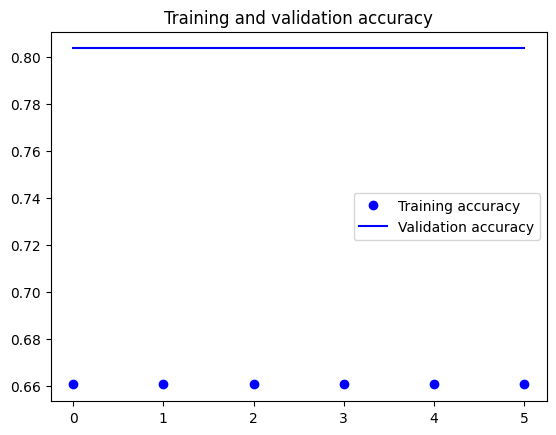

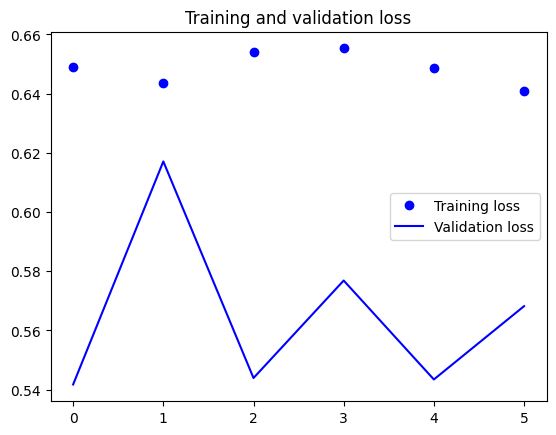

In [13]:
# Rescatar las curvas guardadas durante el entrenamiento
acc, val_acc = history.history["accuracy"], history.history["val_accuracy"]
loss, val_loss = history.history["loss"], history.history["val_loss"]
epochs = range(len(acc))  # eje x: numero de epoch

# Curva de accuracy: la que manda es la de validacion (fotos que no entrenan)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
# Curva de perdida: mas baja = mejor; si train baja pero validacion sube, memoriza (overfitting)
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()


## 5. Evaluación y métricas

Se realizan métricas de performance: además de `accuracy/loss` se agregan matriz de confusión y reporte (precisión/recall/F1), claves en inspección industrial donde un falso negativo cuesta más.

[0.6215784549713135, 0.6901408433914185]
              precision    recall  f1-score   support

        good       0.69      1.00      0.82        49
  defectuosa       0.00      0.00      0.00        22

    accuracy                           0.69        71
   macro avg       0.35      0.50      0.41        71
weighted avg       0.48      0.69      0.56        71



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


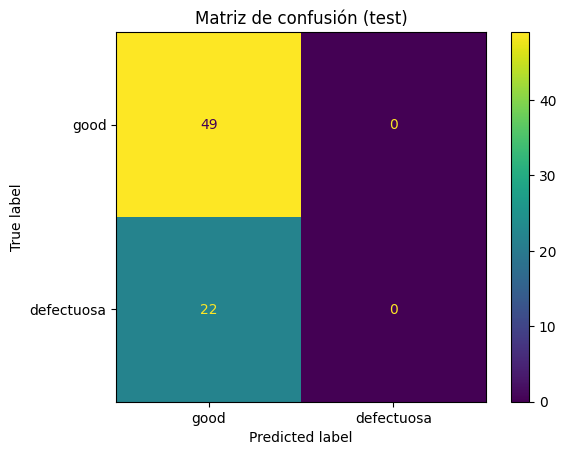

In [14]:
print(model.evaluate(X_test, y_test, verbose=0))  # loss y accuracy en fotos nunca vistas

# Convertir probabilidades en decisiones: mas de 0.5 = defectuosa
y_pred = (model.predict(X_test, verbose=0).ravel() > 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=["good", "defectuosa"]))  # precision/recall/F1

# Tabla 2x2: cuantas buenas y defectuosas acierta, y donde se equivoca
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred), display_labels=["good", "defectuosa"]
).plot()
plt.title("Matriz de confusión (test)")
plt.show()


## 6. Transfer Learning — VGG16 congelado

El mismo esquema del ejemplo del profesor (`transfer_learning.ipynb`, celdas 9–15): una base pre-entrenada en ImageNet aporta los filtros visuales y **solo el cabezal denso aprende** a distinguir buena vs. defectuosa.

Claves:
- `include_top=False` y `trainable = False` **antes** del `compile`.
- Se usa `preprocess_input` de VGG16 (paso a BGR + resta de media de ImageNet), **no** `Rescaling`.
- Los arrays `X_*` están en 0–255 (el `Rescaling` vive dentro de la CNN baseline), así que sirven directo.
- La primera ejecución descarga los pesos `imagenet` (~528 MB).


In [15]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input  # cerebro experto + su "idioma"

# Cargar VGG16 con su conocimiento de ImageNet, sin su cabeza original (pondremos la nuestra)
base_tl = VGG16(weights="imagenet", include_top=False, input_shape=(150, 150, 3))
base_tl.trainable = False  # congelar ANTES de compilar: la base no aprende, solo el cabezal

# Misma cabeza que la CNN: aplanar + Dense 50/20/1 (comparacion justa)
model_tl = Sequential([
    base_tl,
    layers.Flatten(),  # igual que el ejemplo del profesor
    layers.Dense(50, activation="relu"),
    layers.Dense(20, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model_tl.summary()  # fijate en "non-trainable params": la base no aprende


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │       409,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,125,379 (57.70 MB)

 Trainable params: 410,691 (1.57 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [16]:
# Preparar las fotos en el "idioma" de VGG16 (copias nuevas para no pisar los originales)
X_train_tl = preprocess_input(X_train.copy())
X_test_tl = preprocess_input(X_test.copy())

# Compilar igual que la CNN (misma receta: la comparacion es justa)
model_tl.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Mismo freno automatico que antes
es_tl = EarlyStopping(monitor="val_accuracy", mode="max", patience=5, restore_best_weights=True)

# Entrenar: como la base esta congelada, solo el cabezal aprende
history_tl = model_tl.fit(
    X_train_tl, y_train, epochs=50, batch_size=32,
    validation_split=0.2, callbacks=[es_tl],
)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 82s 12s/step - accuracy: 0.5804 - loss: 2.3955 - val_accuracy: 0.2321 - val_loss: 2.1776
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 82s 12s/step - accuracy: 0.6116 - loss: 1.3275 - val_accuracy: 0.2500 - val_loss: 1.5688
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 75s 11s/step - accuracy: 0.6473 - loss: 0.7833 - val_accuracy: 0.6607 - val_loss: 0.7211
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 78s 12s/step - accuracy: 0.8170 - loss: 0.3764 - val_accuracy: 0.8750 - val_loss: 0.3748
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 72s 11s/step - accuracy: 0.8438 - loss: 0.3506 - val_accuracy: 0.8571 - val_loss: 0.4095
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 82s 11s/step - accuracy: 0.8214 - loss: 0.4172 - val_accuracy: 0.8571 - val_loss: 0.4193
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 88s 12s/step - accuracy: 0.8661 - loss: 0.2955 - val_accuracy: 0.7857 - val_loss: 0.5128
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 82s 12s/step - accuracy: 0.9107 - loss: 0.2327 - val_accuracy: 0.6607 - val_loss: 0.8096


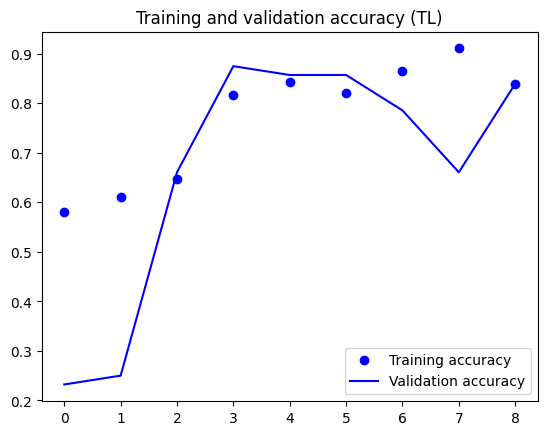

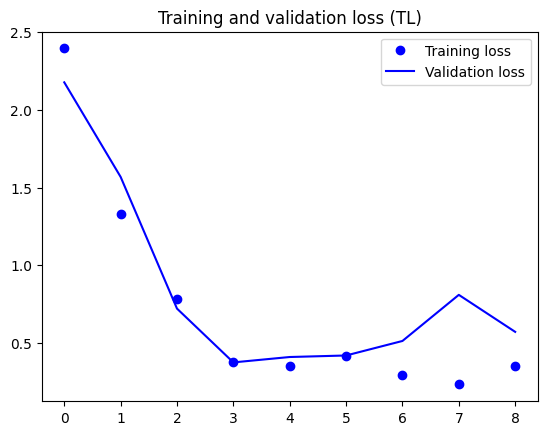

In [17]:
# Mismas curvas que la CNN, ahora para el Transfer Learning
acc, val_acc = history_tl.history["accuracy"], history_tl.history["val_accuracy"]
loss, val_loss = history_tl.history["loss"], history_tl.history["val_loss"]
epochs = range(len(acc))  # eje x: numero de epoch

plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy (TL)")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss (TL)")
plt.legend()
plt.show()


[0.4113270938396454, 0.8028169274330139]
              precision    recall  f1-score   support

        good       0.83      0.90      0.86        49
  defectuosa       0.72      0.59      0.65        22

    accuracy                           0.80        71
   macro avg       0.78      0.74      0.76        71
weighted avg       0.80      0.80      0.80        71



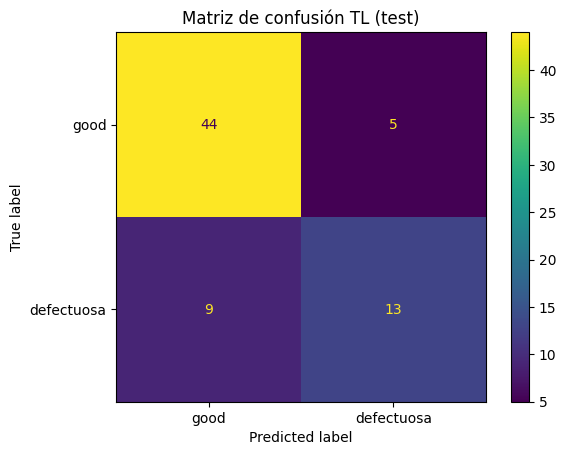

In [18]:
print(model_tl.evaluate(X_test_tl, y_test, verbose=0))  # loss y accuracy del TL en el test

# Mismas decisiones que la CNN (> 0.5 = defectuosa); se guardan porque el FT pisa el modelo
y_pred_tl = (model_tl.predict(X_test_tl, verbose=0).ravel() > 0.5).astype(int)
print(classification_report(y_test, y_pred_tl, target_names=["good", "defectuosa"]))

# Matriz 2x2 del TL para comparar contra la CNN
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_tl), display_labels=["good", "defectuosa"]
).plot()
plt.title("Matriz de confusión TL (test)")
plt.show()


## 7. Fine-Tuning — descongelar el último bloque

Partimos del modelo TL ya entrenado y liberamos **solo el bloque convolucional final** (`block5_*` de VGG16) para adaptarlo a la textura de las cápsulas, re-entrenando con learning rate muy bajo (`Adam(1e-5)`).

Por qué así: con LR normal, o descongelando toda la base, se destruyen los pesos de ImageNet. Y ojo: después de tocar `trainable` hay que **recompilar** para que tenga efecto.


In [19]:
# Descongelar la base pero dejar que aprendan SOLO las 3 capas del ultimo bloque
base_tl.trainable = True
for layer in base_tl.layers:
    layer.trainable = layer.name.startswith("block5_conv")  # solo filtros de alto nivel
print("Capas que ahora aprenden:", [l.name for l in base_tl.layers if l.trainable])

# Recompilar con paso de correccion 100x mas chico: ajuste fino, no reescritura
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # LR bajo: no destruye lo aprendido en ImageNet
    loss="binary_crossentropy", metrics=["accuracy"],
)

# Paciencia mas corta (3): con un paso tan chico, si no mejora rapido no va a mejorar
es_ft = EarlyStopping(monitor="val_accuracy", mode="max", patience=3, restore_best_weights=True)

# Re-entrenar 15 epochs sobre las mismas fotos ya preparadas para VGG16
history_ft = model_tl.fit(
    X_train_tl, y_train, epochs=15, batch_size=32,
    validation_split=0.2, callbacks=[es_ft],
)


Capas que ahora aprenden: ['block5_conv1', 'block5_conv2', 'block5_conv3']
Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 93s 13s/step - accuracy: 0.8571 - loss: 0.3406 - val_accuracy: 0.8571 - val_loss: 0.4241
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 94s 14s/step - accuracy: 0.9196 - loss: 0.2128 - val_accuracy: 0.8393 - val_loss: 0.5383
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 136s 13s/step - accuracy: 0.9375 - loss: 0.1908 - val_accuracy: 0.8393 - val_loss: 0.5177
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 89s 13s/step - accuracy: 0.9464 - loss: 0.1579 - val_accuracy: 0.8214 - val_loss: 0.4260


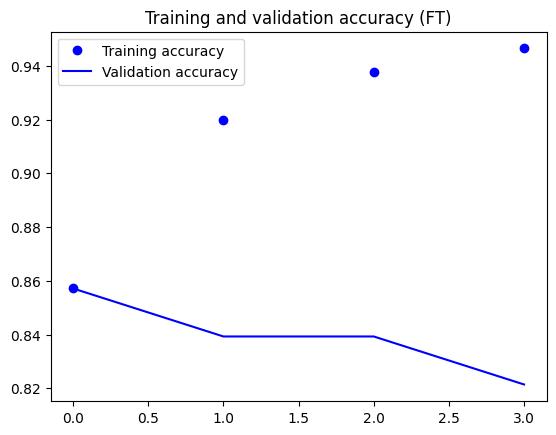

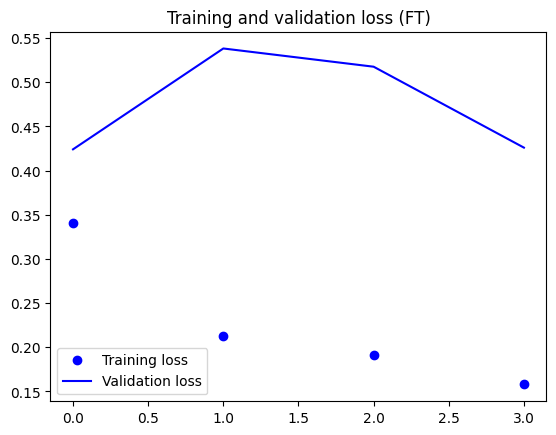

[0.35854145884513855, 0.8309859037399292]


              precision    recall  f1-score   support

        good       0.88      0.88      0.88        49
  defectuosa       0.73      0.73      0.73        22

    accuracy                           0.83        71
   macro avg       0.80      0.80      0.80        71
weighted avg       0.83      0.83      0.83        71



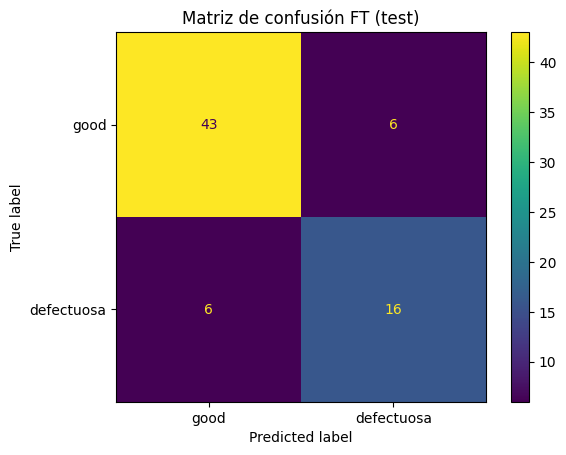

In [20]:
# Curvas del modelo ajustado (igual lectura que antes)
acc, val_acc = history_ft.history["accuracy"], history_ft.history["val_accuracy"]
loss, val_loss = history_ft.history["loss"], history_ft.history["val_loss"]
epochs = range(len(acc))  # eje x: numero de epoch

plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy (FT)")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss (FT)")
plt.legend()
plt.show()

print(model_tl.evaluate(X_test_tl, y_test, verbose=0))  # loss y accuracy finales del FT

# Decisiones del modelo ajustado (> 0.5 = defectuosa) + reporte y matriz 2x2
y_pred_ft = (model_tl.predict(X_test_tl, verbose=0).ravel() > 0.5).astype(int)
print(classification_report(y_test, y_pred_ft, target_names=["good", "defectuosa"]))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_ft), display_labels=["good", "defectuosa"]
).plot()
plt.title("Matriz de confusión FT (test)")
plt.show()


## 8. Comparativa CNN → TL → FT

Los tres enfoques sobre el **mismo** split de test. Se usan los arrays de predicciones ya guardados (`y_pred`, `y_pred_tl`) más la predicción fresca del modelo fine-tuneado — por eso hay que correr las celdas en orden.

Lo esperable con tan pocos datos: `CNN < TL`, y `FT` igual o un poco mejor que `TL`.


In [21]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Resume una corrida en una fila: acc + precision/recall/F1 de la clase defectuosa
def scores_row(name, yt, yp):
    acc = accuracy_score(yt, yp)  # % de aciertos total
    prec, rec, f1, _ = precision_recall_fscore_support(yt, yp, average="binary", zero_division=0)
    print(f"{name:15s} acc={acc:.4f}  precision={prec:.4f}  recall={rec:.4f}  f1={f1:.4f}")

print("--- test (mismo split) ---")  # las 3 filas usan el mismo test: comparacion justa
scores_row("CNN desde cero", y_test, y_pred)  # decisiones guardadas de la CNN
scores_row("TL congelado", y_test, y_pred_tl)  # decisiones guardadas del TL (el FT piso el modelo)
scores_row("FT bloque5", y_test, y_pred_ft)  # decisiones frescas del modelo ajustado


--- test (mismo split) ---
CNN desde cero  acc=0.6901  precision=0.0000  recall=0.0000  f1=0.0000
TL congelado    acc=0.8028  precision=0.7222  recall=0.5909  f1=0.6500
FT bloque5      acc=0.8310  precision=0.7273  recall=0.7273  f1=0.7273


## 9. Informe Final y Análisis Exhaustivo de Resultados

### 9.1 Problema Industrial Abordado
En entornos de producción farmacéutica automáticos, la detección visual de defectos en cápsulas es un desafío de alta prioridad. Un falso negativo (dejar pasar una cápsula defectuosa) puede comprometer la seguridad del lote y violar normativas de salud. Un falso positivo (descartar una pieza buena) genera costos de desperdicio innecesarios.

Este proyecto aborda la **clasificación binaria de cápsulas** en estado **Bueno (0)** o **Defectuoso (1)** utilizando tres arquitecturas distintas de Deep Learning.

---

### 9.2 Distribución del Dataset y Desbalance
- **Total de datos:** 351 imágenes (150x150 píxeles, RGB).
- **Desbalance de Clases:** 242 Buenas vs. 109 Defectuosas (Relación aproximada ~ 70% - 30%).

El desbalance es un factor crítico: si un modelo básico no logra generalizar, adoptará la estrategia trivial de clasificar todo como "bueno" para asegurar de manera simple un 69% de exactitud (*accuracy*), lo cual es inútil para la detección de anomalías.

---

### 9.3 Análisis Exhaustivo de los Desarrollos y Resultados

A continuación, se discute el comportamiento métrico e interno observado durante las pruebas:

| Arquitectura | Accuracy | Precisión (Fallas) | Recall / Sensibilidad | F1-Score | Diagnóstico Técnico |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **1. CNN desde cero** | **69.01%** | **0.00%** | **0.00%** | **0.00%** | **Colapso por desbalance.** El modelo no extrae características útiles y predice siempre la clase mayoritaria.
| **2. Transfer Learning (VGG16)** | **80.28%** | **72.22%** | **59.09%** | **65.00%** | **Éxito en extracción.** Los filtros preentrenados en ImageNet capturan bordes y texturas genéricas de inmediato.
| **3. Fine-Tuning (Bloque 5)** | **83.10%** | **72.73%** | **72.73%** | **72.73%** | **Especialización óptima.** Ajustar los filtros de alto nivel adapta el modelo a la geometría específica de las cápsulas. |

---

### 9.4 Discusión de Resultados por Enfoque

#### A. La CNN desde cero y el "Atractor del Desbalance"
Como se observa en los resultados del punto 5, la CNN básica obtuvo un **accuracy del 69.01%**, pero un **recall y precisión del 0%** para la clase defectuosa.
- **Por qué ocurrió:** Al entrenar desde cero con solo 280 imágenes de entrenamiento, la red no logra configurar filtros espaciales complejos (como grietas o micro-rayas). Como la función de pérdida penaliza el error global, el optimizador minimiza la pérdida rápidamente asumiendo que *todas* las muestras son buenas. El modelo se convierte en un clasificador constante ineficiente para el control de calidad.

#### B. El Salto Cualitativo con Transfer Learning (TL)
Al congelar VGG16 y entrenar únicamente el cabezal clasificador, el accuracy subió al **80.28%** y el F1-score de fallas escaló a **0.65**.
- **Por qué ocurrió:** Aunque VGG16 fue entrenada con objetos comunes (animales, vehículos, etc.), sus primeros bloques ya tienen detectores de bordes, cambios de contraste y texturas que resultan altamente transferibles. El cabezal denso pudo mapear esas formas abstractas para identificar las anomalías.

#### C. El Impacto de Fine-Tuning (FT)
Al descongelar el `block5` de la red preentrenada utilizando un optimizador extremadamente lento (`Learning Rate = 1e-5`), el accuracy subió a **83.10%** y el **recall aumentó drásticamente de 59.09% a 72.73%**.
- **Por qué ocurrió:** Las últimas capas de VGG16 capturan patrones complejos de alta jerarquía. Al especializar estas últimas capas, el modelo aprendió la "normalidad geométrica" de una cápsula farmacéutica cilíndrica y detectó variaciones mínimas de textura (como abolladuras o impresiones corridas).
- **Impacto de Negocio:** Incrementar el Recall al **72.73%** significa que el sistema detecta significativamente más piezas defectuosas en la línea de montaje que la versión congelada, reduciendo la tasa de escape de productos fallados.

---

### 9.5 Conclusiones del Proyecto
1. **Los datos pequeños requieren transferencia:** Intentar entrenar una arquitectura convolucional profunda desde cero sobre datasets industriales pequeños (< 1000 imágenes) suele resultar en sobreajuste o colapso por desbalance.
2. **El ajuste fino es progresivo:** El uso de tasas de aprendizaje bajas (`1e-5`) en Fine-Tuning es fundamental para evitar la "amnesia catastrófica" del conocimiento previo de la red.
3. **Métrica clave:** En inspección de calidad, el **Recall** y el **F1-Score** de la clase defectuosa son las métricas reales del éxito del proyecto, y el Fine-Tuning demostró ser la única estrategia viable para maximizar esta sensibilidad.